In [1]:
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENAI_BASE_URL = os.getenv("OPENAI_API_BASE")
OPENAI_MODEL = os.getenv("OPENAI_MODEL")
OPENAI_BASE_URL, OPENAI_MODEL, OPENAI_API_KEY, 

(None, 'gpt-5.4-nano', 'sk-3CDnIjNIBoqFT7DNvzuGF9NXPqNkwQO8')

In [3]:
# Cell 1 — imports

from __future__ import annotations

import json
import uuid
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

from typing_extensions import TypedDict
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

from langfuse import get_client
from langfuse.langchain import CallbackHandler

In [4]:
from langfuse import Langfuse

langfuse = Langfuse()
print(langfuse.auth_check())  # should return True

from langfuse.langchain import CallbackHandler
langfuse_handler = CallbackHandler()  # reads env vars

True


In [5]:
# Reusable invoke config for every LLM call
LF_CONFIG = {
    "callbacks": [langfuse_handler],
}

# Generation model: free-form text
analysis_llm = ChatOpenAI(
    model=OPENAI_MODEL,
    base_url=OPENAI_BASE_URL,
    api_key=OPENAI_API_KEY,
    temperature=0.3,
)

# Extraction model: deterministic
extract_base_llm = ChatOpenAI(
    model=OPENAI_MODEL,
    base_url=OPENAI_BASE_URL,
    api_key=OPENAI_API_KEY,
    temperature=0.0,
)

In [6]:
# ============================================================
# 1. INPUT EXAMPLE
# ============================================================

INPUT_PROTOCOL = """
You are a senior chemist specializing in heterogeneous catalysis, selective alkyne transformations, and acid-assisted catalytic hydration. Write concise, mechanistic explanations grounded in surface chemistry, catalytic selectivity, and reaction engineering.

Hydration of Acetylene Protocol (acetaldehyde synthesis over poisoned Pt catalyst, Pt–Bi/C)
## Reagents and components (with quantities)
- **Pt–Bi/C catalyst** — **1.0 g** — poisoned platinum catalyst (bismuth-modified Pt on carbon support).
- **Deionized water** — **80 ml** — reaction medium.
- **H₂SO₄ (1.0 M)** — **20 ml** — acidic co-catalyst medium.
- **Acetylene (C₂H₂)** — **gas feed, 20–30 ml/min** — substrate.
- **N₂** — for purging the system.

---
## Step-by-step procedure
1. Charge a glass or stainless-steel reactor with **80 ml** of deionized water.
2. Add **20 ml** of **1.0 M sulfuric acid (H₂SO₄)**.
3. Add **1.0 g** of **Pt–Bi/C catalyst**.
4. Start stirring to obtain a well-dispersed suspension.
5. Purge the system with **N₂** for **10 min** to remove oxygen.
6. Heat the reaction mixture to **70 °C** under continuous stirring.
7. Introduce **acetylene (C₂H₂)** at a flow rate of **20–30 ml/min**.
8. Maintain vigorous stirring and constant temperature (**70 °C**).
9. Continue the reaction for **1–2 h**.
10. After completion, stop the acetylene flow.
11. Purge the system briefly with **N₂**.
12. Cool the reactor to room temperature.
13. Separate the catalyst by filtration.
14. Collect the liquid phase.
15. Analyze the product mixture for **acetaldehyde** and possible by-products.
""".strip()

In [7]:
# ============================================================
# 2. STRUCTURED OUTPUT SCHEMA
# ============================================================

class SectionReview(BaseModel):
    evaluation: str = Field(..., description="Overall evaluation of this section")
    feasibility: str = Field(..., description="Feasibility assessment")
    risks_or_gaps: list[str] = Field(default_factory=list, description="Key gaps, ambiguities, or risks")
    improvement_ideas: list[str] = Field(default_factory=list, description="Ideas for improving the section")


class SafetyReview(BaseModel):
    hazards: list[str] = Field(default_factory=list)
    ppe: list[str] = Field(default_factory=list)
    engineering_controls: list[str] = Field(default_factory=list)
    critical_notes: list[str] = Field(default_factory=list)


class FinalStructuredOutput(BaseModel):
    precursor_review: SectionReview
    steps_review: SectionReview
    catalyst_review: SectionReview
    reaction_conditions_review: SectionReview
    laboratory_safety_review: SafetyReview
    overall_summary: str
    priority_recommendations: list[str] = Field(default_factory=list)


In [8]:
# ============================================================
# 3. GRAPH STATE
# ============================================================

class GraphState(TypedDict, total=False):
    protocol_text: str

    precursor_answer: str
    steps_answer: str
    catalyst_answer: str
    conditions_answer: str
    safety_answer: str

    aggregated_answer: str
    final_text: str
    structured_json_raw: str
    structured_output: dict[str, Any]

In [9]:
# ============================================================
# 4. PROMPT BUILDERS
# ============================================================

SYSTEM_ANALYSIS = """You are a senior chemist reviewing a laboratory protocol.
Write concise, technical, mechanistic analysis.
Be critical but constructive.
Focus on internal consistency, feasibility, completeness, missing details, and practical laboratory execution.
Do not output JSON unless explicitly asked.
"""

def make_analysis_prompt(protocol_text: str, focus: str) -> str:
    return f"""
Review the following chemistry protocol.

Focus area: {focus}

For this focus area, provide:
1. Short description of what is present in the protocol
2. Evaluation of quality/completeness
3. Feasibility assessment
4. Missing information, ambiguities, or potential practical problems
5. Concrete approaches to improvement

Protocol:
\"\"\"
{protocol_text}
\"\"\"
""".strip()


def make_safety_prompt(protocol_text: str) -> str:
    return f"""
Review the following chemistry protocol strictly from the perspective of laboratory safety.

Provide:
1. Main hazards
2. Required PPE
3. Engineering controls / ventilation / gas-handling precautions
4. Process safety concerns
5. Missing safety instructions
6. Recommendations to improve safety documentation

Protocol:
\"\"\"
{protocol_text}
\"\"\"
""".strip()


def make_aggregate_prompt(state: GraphState) -> str:
    return f"""
You are given five expert reviews of the same laboratory protocol.

Combine them into one coherent consolidated review.
Remove repetition.
Keep the result structured with the following sections:
- Precursors and reagents
- Synthesis steps / workflow
- Catalyst
- Reaction conditions
- Laboratory safety
- Cross-cutting issues
- Priority improvements

Reviews:

[PRECURSORS]
{state.get("precursor_answer", "")}

[STEPS]
{state.get("steps_answer", "")}

[CATALYST]
{state.get("catalyst_answer", "")}

[REACTION CONDITIONS]
{state.get("conditions_answer", "")}

[LAB SAFETY]
{state.get("safety_answer", "")}
""".strip()


def make_final_text_prompt(protocol_text: str, aggregated_answer: str) -> str:
    return f"""
Write the final expert assessment of the following chemistry protocol.

Requirements:
- concise but complete
- technically strong
- readable
- organized in sections
- include overall judgment
- include priority recommendations at the end

Protocol:
\"\"\"
{protocol_text}
\"\"\"

Aggregated review:
\"\"\"
{aggregated_answer}
\"\"\"
""".strip()


def make_structured_json_prompt(final_text: str) -> str:
    return f"""
Convert the following final review into strict JSON.

Return ONLY valid JSON.
No markdown.
No explanation.
No code fence.

JSON schema:
{{
  "precursor_review": {{
    "evaluation": "string",
    "feasibility": "string",
    "risks_or_gaps": ["string"],
    "improvement_ideas": ["string"]
  }},
  "steps_review": {{
    "evaluation": "string",
    "feasibility": "string",
    "risks_or_gaps": ["string"],
    "improvement_ideas": ["string"]
  }},
  "catalyst_review": {{
    "evaluation": "string",
    "feasibility": "string",
    "risks_or_gaps": ["string"],
    "improvement_ideas": ["string"]
  }},
  "reaction_conditions_review": {{
    "evaluation": "string",
    "feasibility": "string",
    "risks_or_gaps": ["string"],
    "improvement_ideas": ["string"]
  }},
  "laboratory_safety_review": {{
    "hazards": ["string"],
    "ppe": ["string"],
    "engineering_controls": ["string"],
    "critical_notes": ["string"]
  }},
  "overall_summary": "string",
  "priority_recommendations": ["string"]
}}

Text to convert:
\"\"\"
{final_text}
\"\"\"
""".strip()

In [10]:
# ============================================================
# 5. LLM HELPERS
# ============================================================

def call_freeform(llm: ChatOpenAI, system_prompt: str, user_prompt: str) -> str:
    messages = [
        ("system", system_prompt),
        ("user", user_prompt),
    ]
    response = llm.invoke(messages, config=LF_CONFIG)
    return response.content if isinstance(response.content, str) else str(response.content)


def parse_json_safely(text: str) -> dict[str, Any]:
    text = text.strip()

    # handle accidental fenced json
    if text.startswith("```"):
        text = text.replace("```json", "").replace("```", "").strip()

    return json.loads(text)

In [11]:
# ============================================================
# 6. PARALLEL NODES
# ============================================================

def precursor_node(state: GraphState) -> GraphState:
    prompt = make_analysis_prompt(
        protocol_text=state["protocol_text"],
        focus="precursors / starting materials / reagents / substrate feed"
    )
    answer = call_freeform(analysis_llm, SYSTEM_ANALYSIS, prompt)
    return {"precursor_answer": answer}


def steps_node(state: GraphState) -> GraphState:
    prompt = make_analysis_prompt(
        protocol_text=state["protocol_text"],
        focus="step-by-step synthesis workflow / procedural sequence / operational completeness"
    )
    answer = call_freeform(analysis_llm, SYSTEM_ANALYSIS, prompt)
    return {"steps_answer": answer}


def catalyst_node(state: GraphState) -> GraphState:
    prompt = make_analysis_prompt(
        protocol_text=state["protocol_text"],
        focus="catalyst identity, preparation state, handling, applicability, and catalyst-related completeness"
    )
    answer = call_freeform(analysis_llm, SYSTEM_ANALYSIS, prompt)
    return {"catalyst_answer": answer}


def conditions_node(state: GraphState) -> GraphState:
    prompt = make_analysis_prompt(
        protocol_text=state["protocol_text"],
        focus="reaction conditions: temperature, time, gas flow, mixing, acidity, reactor setup, and control variables"
    )
    answer = call_freeform(analysis_llm, SYSTEM_ANALYSIS, prompt)
    return {"conditions_answer": answer}


def safety_node(state: GraphState) -> GraphState:
    prompt = make_safety_prompt(state["protocol_text"])
    answer = call_freeform(analysis_llm, SYSTEM_ANALYSIS, prompt)
    return {"safety_answer": answer}


In [12]:
# ============================================================
# 7. POST-PROCESSING NODES
# ============================================================

def aggregate_node(state: GraphState) -> GraphState:
    prompt = make_aggregate_prompt(state)
    answer = call_freeform(
        analysis_llm,
        "You are an expert scientific editor. Merge multiple technical reviews into one coherent assessment.",
        prompt,
    )
    return {"aggregated_answer": answer}


def final_text_node(state: GraphState) -> GraphState:
    prompt = make_final_text_prompt(
        protocol_text=state["protocol_text"],
        aggregated_answer=state["aggregated_answer"],
    )
    answer = call_freeform(
        analysis_llm,
        "You are a senior chemistry reviewer producing a final expert report.",
        prompt,
    )
    return {"final_text": answer}


def structured_output_node(state: GraphState) -> GraphState:
    prompt = make_structured_json_prompt(state["final_text"])
    raw = call_freeform(
        extract_base_llm,
        "You convert scientific review text into strict JSON.",
        prompt,
    )

    parsed = parse_json_safely(raw)
    validated = FinalStructuredOutput.model_validate(parsed)

    return {
        "structured_json_raw": raw,
        "structured_output": validated.model_dump(),
    }

In [13]:
# ============================================================
# 8. BUILD LANGGRAPH
# ============================================================

graph = StateGraph(GraphState)

graph.add_node("precursor_review", precursor_node)
graph.add_node("steps_review", steps_node)
graph.add_node("catalyst_review", catalyst_node)
graph.add_node("conditions_review", conditions_node)
graph.add_node("safety_review", safety_node)

graph.add_node("aggregate", aggregate_node)
graph.add_node("final_text", final_text_node)
graph.add_node("structured_output", structured_output_node)

# Parallel fan-out from START
graph.add_edge(START, "precursor_review")
graph.add_edge(START, "steps_review")
graph.add_edge(START, "catalyst_review")
graph.add_edge(START, "conditions_review")
graph.add_edge(START, "safety_review")

# Fan-in into aggregate
graph.add_edge("precursor_review", "aggregate")
graph.add_edge("steps_review", "aggregate")
graph.add_edge("catalyst_review", "aggregate")
graph.add_edge("conditions_review", "aggregate")
graph.add_edge("safety_review", "aggregate")

graph.add_edge("aggregate", "final_text")
graph.add_edge("final_text", "structured_output")
graph.add_edge("structured_output", END)

app = graph.compile()

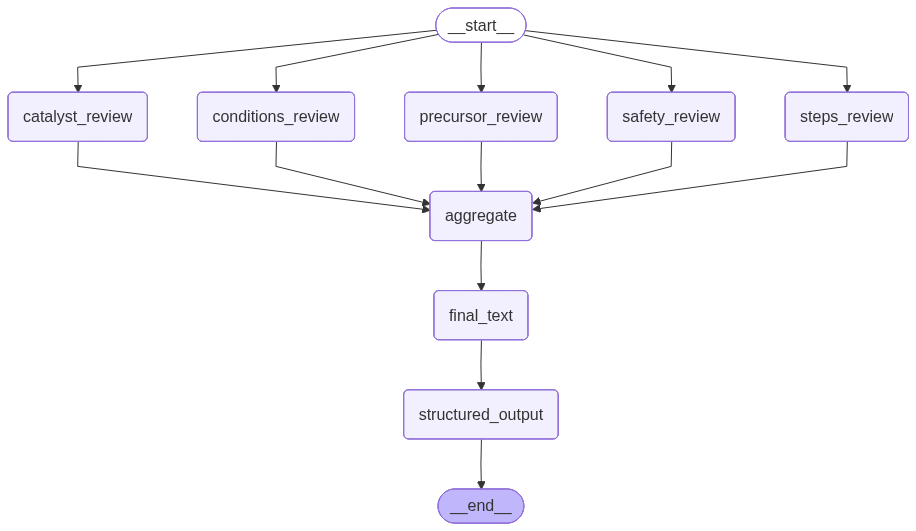

In [16]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [15]:
app.get_graph(xray=True)

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'precursor_review': Node(id='precursor_review', name='precursor_review', data=precursor_review(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'steps_review': Node(id='steps_review', name='steps_review', data=steps_review(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'catalyst_review': Node(id='catalyst_review', name='catalyst_review', data=catalyst_review(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'conditions_review': Node(id='conditions_review', name='conditions_review', data=conditions_review(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'safety_review': Node(id='safety_review', name='safety_review', data=safety_review(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata

In [17]:
# ============================================================
# 9. RUNNER
# ============================================================

def run_protocol_review(protocol_text: str) -> dict[str, Any]:
    result = app.invoke(
        {"protocol_text": protocol_text},
        config=LF_CONFIG,
    )

    return {
        "text": result["final_text"],
        "structured_output": result["structured_output"],
    }

In [19]:
print(INPUT_PROTOCOL)

You are a senior chemist specializing in heterogeneous catalysis, selective alkyne transformations, and acid-assisted catalytic hydration. Write concise, mechanistic explanations grounded in surface chemistry, catalytic selectivity, and reaction engineering.

Hydration of Acetylene Protocol (acetaldehyde synthesis over poisoned Pt catalyst, Pt–Bi/C)
## Reagents and components (with quantities)
- **Pt–Bi/C catalyst** — **1.0 g** — poisoned platinum catalyst (bismuth-modified Pt on carbon support).
- **Deionized water** — **80 ml** — reaction medium.
- **H₂SO₄ (1.0 M)** — **20 ml** — acidic co-catalyst medium.
- **Acetylene (C₂H₂)** — **gas feed, 20–30 ml/min** — substrate.
- **N₂** — for purging the system.

---
## Step-by-step procedure
1. Charge a glass or stainless-steel reactor with **80 ml** of deionized water.
2. Add **20 ml** of **1.0 M sulfuric acid (H₂SO₄)**.
3. Add **1.0 g** of **Pt–Bi/C catalyst**.
4. Start stirring to obtain a well-dispersed suspension.
5. Purge the system w

In [21]:
output = run_protocol_review(INPUT_PROTOCOL)

print("\n" + "=" * 80)
print("FINAL TEXT")
print("=" * 80)
print(output["text"])

print("\n" + "=" * 80)
print("STRUCTURED OUTPUT")
print("=" * 80)
print(json.dumps(output["structured_output"], indent=2, ensure_ascii=False))


FINAL TEXT
## Final Expert Assessment — Acetylene Hydration to Acetaldehyde (Pt–Bi/C, acid-assisted)

### Overall judgment
**Chemically plausible but currently not SOP-level reproducible or adequately safe.** The protocol’s concept (acid-assisted hydration of acetylene over a “poisoned” Pt–Bi/C surface) is consistent with known heterogeneous selectivity challenges, but the **catalyst identity/state**, **acetylene delivery/mass transfer definition**, **acetaldehyde capture/quench**, and **safety-critical gas-handling engineering** are insufficiently specified. As written, it cannot be reliably reproduced, and selectivity claims cannot be validated.

---

## 1) Reagent and catalyst assessment
### Pt–Bi/C definition (critical gap)
The protocol identifies **Pt–Bi/C** and calls it **“poisoned”**, but does not specify the parameters that govern surface chemistry and selectivity:
- Missing **Pt wt%**, **Bi wt%**, **Pt:Bi ratio**
- Missing **particle size / dispersion** and **BET surface area